# Setup

### Imports

In [1]:
# !pip install -r ../requirements.txt

In [2]:
# ---- Standard libraries ----
import os
import sys
import json
import csv
import time
import math
import ast
import copy
import heapq
import random
import pickle
import logging
from datetime import datetime
from collections import defaultdict, namedtuple, deque
from itertools import permutations
from dataclasses import dataclass, field
from typing import Any, Optional, List, Dict

# ---- Data manipulation / visualization ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# ---- Geo-related ----
import geojson
import geopandas as gpd
from shapely.geometry import Point, Polygon
from alphashape import alphashape
import geopy.distance
import networkx as nx
import requests
import overpass  # Overpass API for OpenStreetMap queries

# ---- PyTorch (for RL/deep learning parts) ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---- Removed: this line (was for Colab only) ----
# from google.colab import drive


# Parameters for simulations

In [3]:
# params
ndrivers = 2600
ndeleveries = 2600
thresh_del = 30
baseline = "maddpg" # umst or maddpg

state_name = "Ohio" 
city_name = "Columbus"
mini = True

# Everything Else

### Paths

In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Local data folder
DATA_DIR = PROJECT_ROOT / "Delivery_Data"
DATA_DIR.mkdir(exist_ok=True)

print(f"Using data directory: {DATA_DIR}")

Using data directory: c:\Vishwam\Coding\Project\UMST_approach\Delivery_Data


In [5]:
# --- 5. Set Directories (local/cloud version) ---
from pathlib import Path
import os

try:
    # Step 1: base path (one level up from "Source Code/")
    personal_dir = str(Path.cwd().parent / "Delivery_Data") + "/"

    # Step 2: data folder based on city_name and mini flag
    data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

    # Step 3: output folder (same structure as before)
    output_dir = data_dir + "/UMST Graph/maddpg_baseline"

    # Step 4: create output directory if missing
    os.makedirs(output_dir, exist_ok=True)

    # Step 5: print info
    print(f"Data directory: {data_dir}")
    print(f"Output directory: {output_dir}")

    # Step 6: list contents for sanity check
    data = os.listdir(data_dir)
    print(f"Files in data_dir: {data}")

except Exception as e:
    print(f"Error setting up directories: {e}")
    print(f"Personal Dir Path: {personal_dir}")
    print(f"Data Dir Path: {data_dir}")

Data directory: c:\Vishwam\Coding\Project\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data
Output directory: c:\Vishwam\Coding\Project\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/maddpg_baseline
Files in data_dir: ['avg_hotspot_data.json', 'Census Data', 'Deliveries', 'gh_cache', 'Hotspot Data', 'Images', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'results_fixed_buffer', 'results_multiply', 'results_randomized', 'results_rangewise', 'UMST Graph']


In [6]:
graph_path = data_dir + "/UMST Graph/graphs"
full_graph = graph_path + "/gh_hotspot_graph.graphml.xml"
umst_graph = graph_path + "/umst_graph.graphml.xml"
mst_graph = graph_path + "/mst_graph.graphml.xml"

### Sanity Check

In [7]:
import networkx as nx
import numpy as np

def verify_hotspot_graph(graph_path):
    """
    Load and verify the hotspot graph.
    Ensures node and edge attributes are valid and consistent.
    Returns: nx.Graph object if valid.
    """
    print(f"\n📂 Loading graph from: {graph_path}")
    try:
        G = nx.read_graphml(graph_path)
    except Exception as e:
        raise ValueError(f"❌ Failed to load graph: {e}")

    # Basic info
    print(f"✓ Graph loaded successfully.")
    print(f"   → {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Node checks ---
    missing_latlon = [
        n for n, d in G.nodes(data=True)
        if 'lat' not in d or 'lon' not in d
    ]
    if missing_latlon:
        raise ValueError(f"❌ Some nodes missing lat/lon: {missing_latlon[:5]}")
    else:
        print(f"✓ All nodes have lat/lon attributes.")

    # --- Edge checks ---
    bad_edges = []
    distances, times = [], []
    for u, v, d in G.edges(data=True):
        dist = float(d.get('distance', np.nan))
        time = float(d.get('time', np.nan))
        if np.isnan(dist) or np.isnan(time) or dist <= 0 or time <= 0:
            bad_edges.append((u, v, d))
        else:
            distances.append(dist)
            times.append(time)

    if bad_edges:
        print(f"⚠️ Found {len(bad_edges)} edges with invalid data. Showing first 3:")
        for e in bad_edges[:3]:
            print("   ", e)
    else:
        print(f"✓ All edges have valid distance/time attributes.")

    print(f"📊 Mean distance: {np.mean(distances):.2f} km")
    print(f"📊 Mean travel time: {np.mean(times):.1f} mins")
    sample_edge = list(G.edges(data=True))[0]
    print(f"🔍 Sample edge: {sample_edge}")

    return G


In [8]:
if(baseline == "umst"):
    gtype = mst_graph
else:
    gtype = mst_graph
G = verify_hotspot_graph(gtype)


📂 Loading graph from: c:\Vishwam\Coding\Project\UMST_approach\Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/mst_graph.graphml.xml
✓ Graph loaded successfully.
   → 26 nodes, 25 edges
✓ All nodes have lat/lon attributes.
✓ All edges have valid distance/time attributes.
📊 Mean distance: 1.41 km
📊 Mean travel time: 3.4 mins
🔍 Sample edge: ('39049001110', '39049001000', {'weight': 0.7133257288090575, 'distance': 1.016, 'time': 3.45})


## Delivery Class

In [9]:
@dataclass
class Delivery:
    id: int
    pickup: Any           # node id (string or int depending on your graph)
    dropoff: Any          # node id
    status: str = "waiting"  # one of: waiting, assigned, in_transit, completed, cancelled
    owner: Optional[int] = None    # agent_id if assigned (None if not)

    # --- Time fields (all in minutes, filled by the environment) ---
    spawn_time: Optional[float] = None        # when delivery enters the system
    pickup_time: Optional[float] = None       # when a driver starts serving it
    completion_time: Optional[float] = None   # when it is delivered

    metadata: Dict = field(default_factory=dict)
    
    def assign_to_agent(self, agent_id: int):
        """Mark this delivery as assigned to a given agent."""
        self.owner = agent_id
        self.status = "assigned"
    
    def start_transport(self):
        """Mark that the delivery is now being actively transported."""
        self.status = "in_transit"
    
    def complete(self):
        """Mark this delivery as completed. The env will set completion_time."""
        self.status = "completed"
    
    def to_dict(self):
        return {
            "id": self.id,
            "pickup": self.pickup,
            "dropoff": self.dropoff,
            "status": self.status,
            "owner": self.owner,
            "spawn_time": self.spawn_time,
            "pickup_time": self.pickup_time,
            "completion_time": self.completion_time,
            "metadata": self.metadata
        }
    
    def __repr__(self):
        return (
            f"Delivery(id={self.id}, {self.pickup}->{self.dropoff}, "
            f"status={self.status}, owner={self.owner})"
        )


In [10]:
class DeliveryList:
    """
    A small manager/wrapper around a list of Delivery objects.
    Provides convenience lookups by node (pickup map) and by id.
    """
    def __init__(self, deliveries: Optional[List[Delivery]] = None):
        self.deliveries: List[Delivery] = deliveries[:] if deliveries else []
        self.by_id: Dict[int, Delivery] = {d.id: d for d in self.deliveries}
        self.pickup_map: Dict[Any, List[int]] = {}   # node -> list of delivery ids (waiting)
        self._rebuild_pickup_map()
    
    def _rebuild_pickup_map(self):
        self.pickup_map = {}
        for d in self.deliveries:
            if d.status == "waiting":
                self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def add_delivery(self, d: Delivery):
        if d.id in self.by_id:
            raise ValueError("delivery id exists")
        self.deliveries.append(d)
        self.by_id[d.id] = d
        if d.status == "waiting":
            self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def pop_next_for_node(self, node_id: Any) -> Optional[Delivery]:
        """Deterministic pop: return the first waiting delivery id for node (or None)."""
        lst = self.pickup_map.get(node_id, [])
        if not lst:
            return None
        did = lst.pop(0)
        d = self.by_id[did]
        # status is still "waiting" here; env will decide what to do next
        return d
    
    def assign_delivery_to_agent(self, delivery_id: int, agent_id: int):
        """
        Mark a waiting delivery as assigned to the given agent and
        remove it from the pickup_map for its pickup node.
        """
        d = self.by_id[delivery_id]
        if d.status != "waiting":
            raise RuntimeError("Trying to assign non-waiting delivery")
        d.assign_to_agent(agent_id)
        # remove from pickup_map
        lst = self.pickup_map.get(d.pickup, [])
        if delivery_id in lst:
            lst.remove(delivery_id)
    
    def remaining_count(self):
        return sum(1 for d in self.deliveries if d.status in ("waiting", "assigned", "in_transit"))
    
    def get_waiting_at_node(self, node_id: Any) -> List[int]:
        return list(self.pickup_map.get(node_id, []))
    
    def to_simple_list(self):
        return [d.to_dict() for d in self.deliveries]


In [11]:
# Display the class definitions so you can copy/paste this into your notebook cell.
Delivery, DeliveryList

(__main__.Delivery, __main__.DeliveryList)

## Generate Deliveries

In [12]:
import random
import networkx as nx

def generate_simple_deliveries(G, num_deliveries=1000, seed=42, max_time_mins=20.0):
    """
    Simplified random delivery generator.
    Creates num_deliveries random (pickup, dropoff) pairs from the graph nodes,
    strictly ensuring the point-to-point travel time is <= max_time_mins.
    """
    random.seed(seed)
    nodes = list(G.nodes())
    deliveries = []
    
    attempts = 0
    max_attempts = num_deliveries * 50  # Safeguard against infinite loops
    
    print(f"Generating {num_deliveries} deliveries (max {max_time_mins} mins travel time)...")
    
    while len(deliveries) < num_deliveries and attempts < max_attempts:
        attempts += 1
        pickup, dropoff = random.sample(nodes, 2)  # ensure pickup != dropoff
        
        try:
            # Calculate shortest path time using the graph's 'time' edge weights
            travel_time = nx.shortest_path_length(G, source=pickup, target=dropoff, weight='time')
            
            if travel_time <= max_time_mins:
                # Create the delivery and store the calculated time in metadata
                d = Delivery(
                    id=len(deliveries), 
                    pickup=pickup, 
                    dropoff=dropoff, 
                    status="waiting"
                )
                d.metadata['estimated_time'] = travel_time
                deliveries.append(d)
                
        except nx.NetworkXNoPath:
            # If nodes are in disconnected components of the graph, simply ignore and try again
            continue
            
    if len(deliveries) < num_deliveries:
        print(f"⚠️ Warning: Could only generate {len(deliveries)} deliveries within {max_attempts} attempts.")
    else:
        print(f"✅ Generated {len(deliveries)} deliveries between {len(nodes)} nodes.")
        
    delivery_list = DeliveryList(deliveries)
    
    if deliveries:
        sample_time = deliveries[0].metadata.get('estimated_time', 0)
        print(f"Example: {deliveries[0]} (Est. Time: {sample_time:.1f} mins)")
        
    return delivery_list

In [13]:
import matplotlib.pyplot as plt

def plot_deliveries_on_graph(G, delivery_list, sample_size=100):
    """
    Quick visual check: plots the hotspot graph (using lat/lon)
    and overlays sampled pickup → dropoff connections.
    """
    plt.figure(figsize=(10, 8))

    # Extract positions from node lat/lon
    pos = {n: (float(d['lon']), float(d['lat'])) for n, d in G.nodes(data=True)}

    # Draw the base graph (light gray edges, small nodes)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.5, width=0.8)
    nx.draw_networkx_nodes(G, pos, node_size=40, node_color='gray')

    # Sample deliveries to display (avoid clutter)
    sample_deliveries = random.sample(delivery_list.deliveries, min(sample_size, len(delivery_list.deliveries)))

    for d in sample_deliveries:
        pickup_pos = pos[d.pickup]
        dropoff_pos = pos[d.dropoff]
        plt.plot(
            [pickup_pos[0], dropoff_pos[0]],
            [pickup_pos[1], dropoff_pos[1]],
            color='tab:blue', alpha=0.6, linewidth=1.5
        )
        plt.scatter(*pickup_pos, color='green', s=30, zorder=5)
        plt.scatter(*dropoff_pos, color='red', s=30, zorder=5)

    plt.title(f"Sample of {len(sample_deliveries)} Deliveries (Pickup=Green, Dropoff=Red)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


## Delivery Enviornment: 
literaly handles everything

In [14]:
# -------------------- DeliveryEnvironment (updated) --------------------
import networkx as nx
import numpy as np
import random
from typing import Dict, Any, List, Optional, Tuple

STATE_IDLE = 0
STATE_SINGLE = 1
STATE_DOUBLE = 2


class DeliveryEnvironment:
    def __init__(self, G: nx.Graph, delivery_list: 'DeliveryList', num_agents: int = 10, seed: int = 42):
        random.seed(seed)
        np.random.seed(seed)
        self.G = G
        self.node_list = list(G.nodes())
        self.node_index = {n: i for i, n in enumerate(self.node_list)}
        self.N_nodes = len(self.node_list)

        # --- Precompute distance/time matrices ---
        self.distance_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)
        self.time_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)

        for i, u in enumerate(self.node_list):
            length_dist = nx.single_source_dijkstra_path_length(self.G, u, weight='distance')
            length_time = nx.single_source_dijkstra_path_length(self.G, u, weight='time')
            for v, val in length_dist.items():
                j = self.node_index[v]
                self.distance_matrix[i, j] = val
            for v, val in length_time.items():
                j = self.node_index[v]
                self.time_matrix[i, j] = val

        finite_max = np.nanmax(self.distance_matrix[np.isfinite(self.distance_matrix)]) if np.any(
            np.isfinite(self.distance_matrix)) else 1.0
        self.distance_matrix[~np.isfinite(self.distance_matrix)] = finite_max * 10.0
        self.time_matrix[~np.isfinite(self.time_matrix)] = np.nanmax(
            self.time_matrix[np.isfinite(self.time_matrix)]
        ) * 10.0 if np.any(np.isfinite(self.time_matrix)) else 1.0

        self.max_pair_dist = float(np.max(self.distance_matrix))

        # --- Deliveries & Agents ---
        self.delivery_list = delivery_list
        self.pickup_map = dict(self.delivery_list.pickup_map)
        self.num_agents = num_agents
        self.agents: Dict[int, Dict[str, Any]] = {}
        
        # Track pairs waiting to bundle across steps (Just-In-Time logic)
        self.pending_bundles = {} 

        # --- Time + stats ---
        self.step_count = 0
        self.current_time = 0.0

        self.episode_stats = {
            'total_deliveries': 0, 'bundles_created': 0, 'distance_saved_sum': 0.0,
            'bundle_attempts': 0, 'successful_bundles': 0, 'avg_delivery_time': 0.0,
            'successful_deliveries': 0, 'failed_deliveries': 0, '_sum_service_time': 0.0,
            '_sum_lifetime': 0.0, 'total_driver_distance': 0.0, 'total_package_distance': 0.0,
            'final_completion_time': 0.0,
        }

        # Additional bookkeeping
        self.vehicles_seen = set()
        self.service_times = []
        self.lifetimes = []
        self.delivery_completed_ids = []
        self.bundle_participation_set = set()
        self.per_delivery_records = []
        self.timeline = {
            "timestamps": [], "active_deliveries": [], "bundled_deliveries": [], "total_vehicles_active": []
        }

        self._init_agents_random()


    def _init_agents_random(self):
        self.agents = {}
        available_waiting = [d.id for d in self.delivery_list.deliveries if d.status == 'waiting']

        for aid in range(self.num_agents):
            # If there are more drivers than initial packages, spawn the extras randomly and leave them idle
            if not available_waiting:
                node = random.choice(self.node_list)
                self.agents[aid] = {
                    'current_node': node, 'state': STATE_IDLE, 'deliveries': [], 'path_queue': []
                }
                continue

            did = available_waiting.pop(0)
            d = self.delivery_list.by_id[did]

            # 1. Spawn driver exactly at the package's pickup node
            self.agents[aid] = {
                'current_node': d.pickup,
                'state': STATE_SINGLE,
                'deliveries': [did],
                'path_queue': []
            }

            # 2. Assign the delivery and set timestamps
            self.delivery_list.assign_delivery_to_agent(did, aid)
            if d.spawn_time is None: 
                d.spawn_time = self.current_time
            d.pickup_time = self.current_time

            # 3. Path them directly to the dropoff
            self.agents[aid]['path_queue'] = self._shortest_path_nodes(d.pickup, d.dropoff)

    def _assign_nearest_deliveries_to_idle_agents(self):
        waiting = [d for d in self.delivery_list.deliveries if d.status == "waiting"]
        if not waiting: return

        for aid, info in self.agents.items():
            if info['state'] != STATE_IDLE: continue
            cur_node = info['current_node']
            cur_idx = self.node_index[cur_node]
            best_d, best_del = float('inf'), None
            
            for d in waiting:
                pick_idx = self.node_index[d.pickup]
                dist = self.distance_matrix[cur_idx, pick_idx]
                if dist < best_d: best_d, best_del = dist, d

            if best_del is not None:
                self.delivery_list.assign_delivery_to_agent(best_del.id, aid)
                if best_del.spawn_time is None: best_del.spawn_time = self.current_time
                best_del.pickup_time = self.current_time
                waiting.remove(best_del)
                info['deliveries'].append(best_del.id)
                info['state'] = STATE_SINGLE
                info['path_queue'] = self._shortest_path_nodes(cur_node, best_del.pickup)

    def _shortest_path_nodes(self, src, dst) -> List[Any]:
        if src == dst: return []
        try:
            return nx.shortest_path(self.G, source=src, target=dst, weight='distance')[1:]
        except Exception:
            return []

    def reset(self):
        self.step_count = 0
        self.current_time = 0.0
        self.pending_bundles = {}

        self.timeline = {
            "timestamps": [], "active_deliveries": [], "bundled_deliveries": [], "total_vehicles_active": []
        }
        self.active_vehicle_counts = []

        for d in self.delivery_list.deliveries:
            d.status = "waiting"
            d.owner = None
            d.spawn_time = 0.0
            d.pickup_time = None
            d.completion_time = None

        self.delivery_list._rebuild_pickup_map()
        self.pickup_map = dict(self.delivery_list.pickup_map)

        for k in self.episode_stats:
            self.episode_stats[k] = 0 if k != 'distance_saved_sum' and k != 'avg_delivery_time' else 0.0

        self._init_agents_random()
        self._assign_nearest_deliveries_to_idle_agents()

        obs, info = self._generate_pairs_and_obs()
        info['episode_stats'] = dict(self.episode_stats)
        return obs, info

    def _generate_pairs_and_obs(self) -> Tuple[Dict[int, np.ndarray], Dict]:
        """Scans the map for agents currently co-located and generates observations JIT."""
        obs = {}
        receiver_obs_dict = {}
        
        node_agents: Dict[Any, List[int]] = {}
        for aid, info in self.agents.items():
            if info['state'] == STATE_SINGLE and len(info['deliveries']) == 1:
                node_agents.setdefault(info['current_node'], []).append(aid)

        for node, agent_ids in node_agents.items():
            eligible = sorted(agent_ids)
            for i in range(len(eligible) - 1):
                a, b = eligible[i], eligible[i + 1]
                
                # Skip if already marked for bundling this step
                if a in self.pending_bundles.keys() or a in self.pending_bundles.values(): continue
                if b in self.pending_bundles.keys() or b in self.pending_bundles.values(): continue

                saved = self._compute_pair_saving_at_node(node, a, b)
                if saved > 0.0:
                    proposer = min(a, b)
                    receiver = max(a, b)
                    self.pending_bundles[proposer] = receiver

                    dA = self.node_index[self.delivery_list.by_id[self.agents[proposer]['deliveries'][0]].dropoff]
                    dB = self.node_index[self.delivery_list.by_id[self.agents[receiver]['deliveries'][0]].dropoff]
                    nNode = self.node_index[node]
                    
                    d_prop_drop = float(self.distance_matrix[nNode, dA])
                    d_rec_drop = float(self.distance_matrix[nNode, dB])
                    
                    # FIX: Add the distance between the two dropoffs
                    dist_between_drops = float(self.distance_matrix[dA, dB])

                    # Pair-specific observation now has 4 dimensions
                    obs[proposer] = np.array([d_prop_drop, d_rec_drop, dist_between_drops, 0.0], dtype=np.float32)
                    receiver_obs_dict[proposer] = np.array([d_rec_drop, d_prop_drop, dist_between_drops, 0.0], dtype=np.float32)

        return obs, {'receiver_obs': receiver_obs_dict}

    def _move_agent_along_path(self, aid) -> float:
        info = self.agents[aid]
        if not info['path_queue']: return 0.0

        prev_node = info['current_node']
        next_node = info['path_queue'].pop(0)
        info['current_node'] = next_node

        prev_idx = self.node_index[prev_node]
        next_idx = self.node_index[next_node]

        travel_time = float(self.time_matrix[prev_idx, next_idx])
        edge_dist = float(self.distance_matrix[prev_idx, next_idx])

        self.episode_stats['total_driver_distance'] += edge_dist
        return travel_time

    def _compute_pair_saving_at_node(self, node_id: Any, aid_a: int, aid_b: int) -> float:
        A, B = self.agents[aid_a], self.agents[aid_b]
        if len(A['deliveries']) != 1 or len(B['deliveries']) != 1: return 0.0

        did_a = A['deliveries'][0]
        did_b = B['deliveries'][0]
        nA, nB = self.node_index[A['current_node']], self.node_index[B['current_node']]
        nNode = self.node_index[node_id]
        dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
        dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]

        package_total = float(self.distance_matrix[nA, dA] + self.distance_matrix[nB, dB])
        to_node = float(self.distance_matrix[nA, nNode] + self.distance_matrix[nB, nNode])

        route1 = float(self.distance_matrix[nNode, dA] + self.distance_matrix[dA, dB])
        route2 = float(self.distance_matrix[nNode, dB] + self.distance_matrix[dB, dA])
        best_receiver_route = min(route1, route2)

        return package_total - (to_node + best_receiver_route)

    def _apply_bundle(self, node_id: Any, proposer_id: int, receiver_id: int, rewards: Dict[int, float]):
        A, B = self.agents[proposer_id], self.agents[receiver_id]
        saved = self._compute_pair_saving_at_node(node_id, proposer_id, receiver_id)
        if saved <= 0.0: return

        # Reward calculation
        normalized = max(-2.0, min(2.0, saved / (self.max_pair_dist + 1e-9)))
        r = 5.0 + 5.0 * normalized
        rewards[proposer_id] += r
        rewards[receiver_id] += r

        did_a = A['deliveries'].pop(0) # Proposer's package
        did_b = B['deliveries'][0]     # Receiver's original package

        self.delivery_list.by_id[did_a].metadata["bundled"] = True
        md = self.delivery_list.by_id[did_a].metadata
        md["times_bundled"] = md.get("times_bundled", 0) + 1
        md["vehicle_changes"] = md.get("vehicle_changes", 0) + 1
        self.bundle_participation_set.add(did_a)
        
        self.delivery_list.by_id[did_a].assign_to_agent(receiver_id)

        # Enforce the mathematically shorter route!
        dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
        dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]
        nNode = self.node_index[node_id]

        route1 = float(self.distance_matrix[nNode, dA] + self.distance_matrix[dA, dB]) # Drop A first
        route2 = float(self.distance_matrix[nNode, dB] + self.distance_matrix[dB, dA]) # Drop B first

        if route1 <= route2:
            B['deliveries'] = [did_a, did_b]
            first_drop = self.delivery_list.by_id[did_a].dropoff
        else:
            B['deliveries'] = [did_b, did_a]
            first_drop = self.delivery_list.by_id[did_b].dropoff

        A['state'] = STATE_IDLE
        A['path_queue'] = []
        B['state'] = STATE_DOUBLE
        B['path_queue'] = self._shortest_path_nodes(B['current_node'], first_drop)

        self.episode_stats['bundles_created'] += 1
        self.episode_stats['successful_bundles'] += 1
        self.episode_stats['distance_saved_sum'] += float(saved)

    def _process_arrivals_and_pickups(self):
        node_agents: Dict[Any, List[int]] = {}
        for aid, info in self.agents.items():
            node_agents.setdefault(info['current_node'], []).append(aid)

        rewards = {aid: 0.0 for aid in self.agents.keys()}
        for node, agent_ids in node_agents.items():
            waiting = self.pickup_map.get(node, [])
            if not waiting: continue

            for aid in sorted(agent_ids):
                info = self.agents[aid]
                if info['state'] == STATE_IDLE:
                    did = waiting.pop(0)
                    self.delivery_list.assign_delivery_to_agent(did, aid)
                    d = self.delivery_list.by_id[did]
                    if d.spawn_time is None: d.spawn_time = self.current_time
                    d.pickup_time = self.current_time
                    info['deliveries'].append(did)
                    info['state'] = STATE_SINGLE
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], d.dropoff)
                    break 

        return rewards

    def step(self, actions: Optional[Dict[int, int]] = None, max_steps: Optional[int] = None):
        self.step_count += 1
        if actions is None: actions = {}
        rewards = {aid: 0.0 for aid in self.agents.keys()}

        # 1) --- Bundling Stage (Execute decisions on pairs found at the end of last step) ---
        for proposer, receiver in list(self.pending_bundles.items()):
            if baseline == "umst" or actions.get(proposer, 0) == 1:
                # Sanity check: ensure they are still at the same node
                if (self.agents[proposer]['state'] == STATE_SINGLE and 
                    self.agents[receiver]['state'] == STATE_SINGLE and 
                    self.agents[proposer]['current_node'] == self.agents[receiver]['current_node']):
                    node = self.agents[proposer]['current_node']
                    self._apply_bundle(node, proposer, receiver, rewards)
        self.pending_bundles.clear() # Clear out processed pairs

        # 2) --- Movement Stage ---
        step_travel_times: List[float] = []
        for aid in sorted(self.agents.keys()):
            travel_time = self._move_agent_along_path(aid)
            if travel_time > 0.0: step_travel_times.append(travel_time)

        step_duration = sum(step_travel_times) / len(step_travel_times) if step_travel_times else 0.0
        self.current_time += step_duration

        # 3) --- Pickups ---
        pickup_rewards = self._process_arrivals_and_pickups()
        for k, v in pickup_rewards.items(): rewards[k] += v

        # 4) --- Dropoffs ---
        for aid, info in self.agents.items():
            if not info['deliveries']: continue

            first_did = info['deliveries'][0]
            d_obj = self.delivery_list.by_id[first_did]
            if info['current_node'] != d_obj.dropoff: continue

            d_obj.complete()
            d_obj.completion_time = self.current_time
            rewards[aid] += 5.0

            service_time = d_obj.completion_time - d_obj.pickup_time if d_obj.pickup_time is not None else 0.0
            lifetime = d_obj.completion_time - d_obj.spawn_time if d_obj.spawn_time is not None else 0.0

            self.service_times.append(service_time)
            self.lifetimes.append(lifetime)
            self.delivery_completed_ids.append(first_did)
            self.vehicles_seen.add(aid)

            n_p, n_q = self.node_index[d_obj.pickup], self.node_index[d_obj.dropoff]
            pkg_dist = float(self.distance_matrix[n_p, n_q])
            self.episode_stats['total_package_distance'] += pkg_dist

            try:
                expected_travel_time = float(self.time_matrix[n_p, n_q])
            except Exception: expected_travel_time = None

            md = d_obj.metadata or {}
            threshold = float(globals().get("thresh_del", 0))
            
            per_rec = {
                "id": int(d_obj.id), "start_node": int(n_p), "end_node": int(n_q),
                "start_time": float(d_obj.spawn_time), "end_time": float(d_obj.completion_time),
                "actual_delivery_time": float(service_time), "expected_travel_time": expected_travel_time,
                "time_limit": float(threshold), "delay": float(lifetime - threshold),
                "within_buffer": bool(lifetime <= threshold), "distance_traveled": float(pkg_dist),
                "num_vehicle_changes": int(md.get("vehicle_changes", 0)),
                "times_bundled": int(md.get("times_bundled", 0)),
                "successful": bool(lifetime <= threshold)
            }
            self.per_delivery_records.append(per_rec)

            if lifetime <= thresh_del:
                self.episode_stats['successful_deliveries'] += 1
            else:
                self.episode_stats['failed_deliveries'] += 1

            self.episode_stats['total_deliveries'] += 1
            self.episode_stats['_sum_service_time'] += service_time
            self.episode_stats['_sum_lifetime'] += lifetime
            self.episode_stats['avg_delivery_time'] = self.episode_stats['_sum_service_time'] / max(1, self.episode_stats['total_deliveries'])

            info['deliveries'].pop(0)

            if info['state'] == STATE_DOUBLE:
                if len(info['deliveries']) == 1:
                    info['state'] = STATE_SINGLE
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], self.delivery_list.by_id[info['deliveries'][0]].dropoff)
                else:
                    info['state'], info['path_queue'] = STATE_IDLE, []
            else:
                if len(info['deliveries']) == 0:
                    info['state'], info['path_queue'] = STATE_IDLE, []
                elif len(info['deliveries']) == 1:
                    info['state'] = STATE_SINGLE
                    info['path_queue'] = self._shortest_path_nodes(info['current_node'], self.delivery_list.by_id[info['deliveries'][0]].dropoff)

        # 5) --- Find eligible bundles for NEXT step (Just-In-Time obs) ---
        obs, info_dict = self._generate_pairs_and_obs()

        # Termination & Timeline
        done = bool((max_steps is not None and self.step_count >= max_steps) or self.delivery_list.remaining_count() == 0)
        if done: self.episode_stats['final_completion_time'] = self.current_time

        try:
            import math
            t_int = int(math.ceil(float(self.current_time)))
            if not (len(self.timeline["timestamps"]) > 0 and self.timeline["timestamps"][-1] == t_int):
                self.timeline["timestamps"].append(t_int)
                self.timeline["active_deliveries"].append(int(sum(1 for d in self.delivery_list.deliveries if d.status in ("assigned", "in_transit"))))
                self.timeline["bundled_deliveries"].append(int(sum(1 for d in self.delivery_list.deliveries if d.metadata.get("bundled", False))))
                
                total_active = sum(1 for a in self.agents.values() if a['state'] != STATE_IDLE)
                self.timeline["total_vehicles_active"].append(int(total_active))
                
                if hasattr(self, "active_vehicle_counts"): self.active_vehicle_counts.append(int(total_active))
                else: self.active_vehicle_counts = [int(total_active)]
        except Exception: pass

        info_dict['step'] = self.step_count
        info_dict['episode_stats'] = dict(self.episode_stats)
        
        return obs, rewards, done, info_dict

In [15]:
deliveries = generate_simple_deliveries(G, num_deliveries=ndeleveries)
env = DeliveryEnvironment(G, deliveries, num_agents=ndrivers)

Generating 2600 deliveries (max 20.0 mins travel time)...
✅ Generated 2600 deliveries between 26 nodes.
Example: Delivery(id=0, 39049001600->39049007830, status=waiting, owner=None) (Est. Time: 18.0 mins)


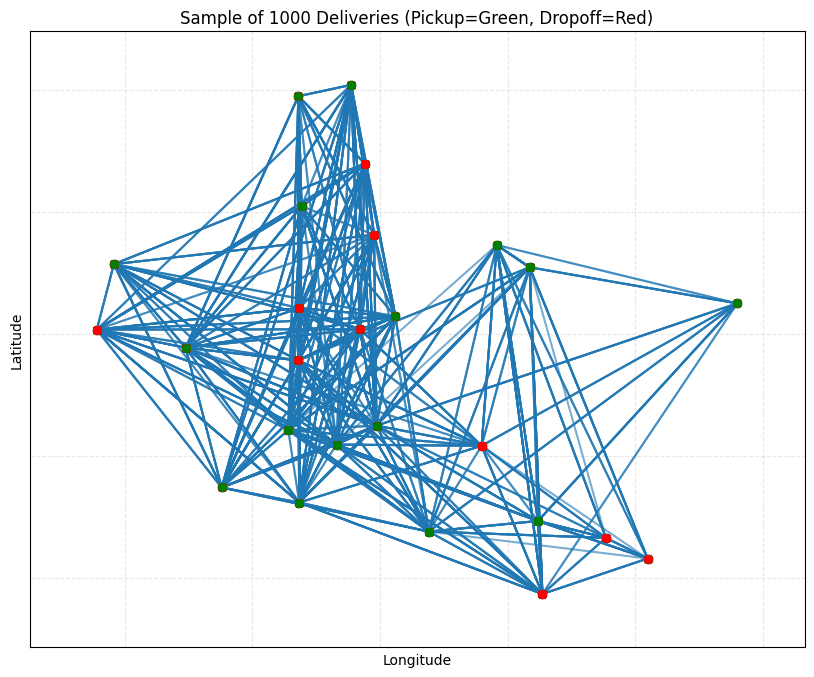

In [16]:
# Example usage (run after generating deliveries)
plot_deliveries_on_graph(G, deliveries, sample_size=1000)

## MADDPG Agent and Agent Coordinator

In [17]:
# ------------------ Cell A: Shared MADDPGAgent (PyTorch) + ReplayBuffer ------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import namedtuple, deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition', [
    'obs_self', 'obs_other',
    'action_self', 'action_other',
    'reward_self', 'reward_other',
    'next_obs_self', 'next_obs_other',
    'done'
])

class ReplayBuffer:
    def __init__(self, capacity=500000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    
    def __len__(self):
        return len(self.buffer)

def mlp(input_dim, hidden_dims, output_dim, final_activation=None):
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.ReLU())
        prev = h
    layers.append(nn.Linear(prev, output_dim))
    if final_activation == 'tanh':
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)

class Actor(nn.Module):
    def __init__(self, obs_dim=4, hidden=(128,64)):
        super().__init__()
        self.net = mlp(obs_dim, hidden, 1)
    def forward(self, x):
        logits = self.net(x).squeeze(-1)
        return torch.sigmoid(logits)

class Critic(nn.Module):
    def __init__(self, input_dim=8, hidden=(256,128)):
        super().__init__()
        self.net = mlp(input_dim, hidden, 1)
    def forward(self, x):
        return self.net(x).squeeze(-1)

class MADDPGAgent:
    """
    Shared Parameter Agent: We only need ONE instance of this class to handle all 86,000 drivers.
    """
    def __init__(self, obs_dim=4, lr_actor=1e-4, lr_critic=1e-3, gamma=0.99, tau=0.01):
        self.obs_dim = obs_dim
        self.gamma = gamma
        self.tau = tau
        
        self.actor = Actor(obs_dim).to(device)
        self.actor_target = Actor(obs_dim).to(device)
        self.critic = Critic(input_dim=obs_dim*2 + 2).to(device)
        self.critic_target = Critic(input_dim=obs_dim*2 + 2).to(device)
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        
        self._hard_update(self.actor_target, self.actor)
        self._hard_update(self.critic_target, self.critic)
    
    def _hard_update(self, target, source):
        target.load_state_dict(source.state_dict())
    
    def soft_update(self):
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
    
    def select_action(self, obs, deterministic=False, eps=0.0):
        if obs is None: return 0, 0.0

        if isinstance(obs, np.ndarray):
            obs_v = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        else:
            obs_v = torch.tensor(np.array(obs), dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            prob = self.actor(obs_v).cpu().item()

        prob = float(min(1.0, max(0.0, prob)))

        if (not deterministic) and (random.random() < eps):
            act = 1 if random.random() < 0.5 else 0
        else:
            act = 1 if prob >= 0.5 else 0

        return int(act), float(prob)
    
    def _build_critic_input(self, obs_self, obs_other, act_self, act_other):
        return torch.cat([obs_self, obs_other, act_self, act_other], dim=-1)
    
    def update(self, batch: Transition):
        if len(batch.obs_self) == 0: return None
        
        obs_self = torch.tensor(np.stack(batch.obs_self), dtype=torch.float32, device=device)
        obs_other = torch.tensor(np.stack(batch.obs_other), dtype=torch.float32, device=device)
        action_self = torch.tensor(np.array(batch.action_self).reshape(-1,1), dtype=torch.float32, device=device)
        action_other = torch.tensor(np.array(batch.action_other).reshape(-1,1), dtype=torch.float32, device=device)
        reward_self = torch.tensor(np.array(batch.reward_self), dtype=torch.float32, device=device)
        
        next_obs_self = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_self]), dtype=torch.float32, device=device)
        next_obs_other = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_other]), dtype=torch.float32, device=device)
        done = torch.tensor(np.array(batch.done).astype(np.float32), dtype=torch.float32, device=device)
        
        # ----- Critic update -----
        with torch.no_grad():
            next_prob_self = self.actor_target(next_obs_self).unsqueeze(-1)
            next_prob_other = self.actor_target(next_obs_other).unsqueeze(-1)
            next_critic_input = self._build_critic_input(next_obs_self, next_obs_other, next_prob_self, next_prob_other)
            target_q = self.critic_target(next_critic_input)
            y = reward_self + (1.0 - done) * self.gamma * target_q
        
        critic_input = self._build_critic_input(obs_self, obs_other, action_self, action_other)
        current_q = self.critic(critic_input)
        critic_loss = F.mse_loss(current_q, y.detach())
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_optimizer.step()
        
        # ----- Actor update -----
        prob_self = self.actor(obs_self).unsqueeze(-1)
        act_other_batch = action_other.detach()
        actor_critic_input = self._build_critic_input(obs_self, obs_other, prob_self, act_other_batch)
        actor_loss = -self.critic(actor_critic_input).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_optimizer.step()
        
        self.soft_update()
        return {'critic_loss': critic_loss.item(), 'actor_loss': actor_loss.item()}

# ------------------ Cell B: AgentCoordinator (Event-based Buffer) ------------------

class AgentCoordinator:
    def __init__(self, env, num_agents=None, buffer_capacity=500000, batch_size=1024,
                 update_after=5000, update_every=50, gamma=0.99, tau=0.01, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
        self.env = env
        self.num_agents = num_agents or env.num_agents
        self.batch_size = batch_size
        self.update_after = update_after
        self.update_every = update_every
        
        self.buffer = ReplayBuffer(capacity=buffer_capacity)
        
        # PARAMETER SHARING: Only one shared network instance.
        self.agent = MADDPGAgent(obs_dim=4, gamma=gamma, tau=tau)
        
        self.total_steps = 0
        self.training_steps = 0
        self.log = []
    
    def collect_and_store(self, obs, info, actions, rewards, next_obs, next_info, done):
        """
        Event-based storage: only stores transitions for drivers who actually had the chance to bundle.
        Eliminates the O(N^2) loop.
        """
        receiver_obs_dict = info.get('receiver_obs', {})
        next_receiver_obs_dict = next_info.get('receiver_obs', {})
        
        for proposer, o_a in obs.items():
            act = actions.get(proposer, 0)
            rew = rewards.get(proposer, 0.0)
            
            # FIX: Change the fallback zero-arrays from 3 to 4 dimensions
            o_b = receiver_obs_dict.get(proposer, np.zeros(4))
            
            # Next states
            no_a = next_obs.get(proposer, np.zeros(4))
            no_b = next_receiver_obs_dict.get(proposer, np.zeros(4))
            
            # act_other is always 0 since receiver is passive
            self.buffer.push(o_a, o_b, act, 0.0, rew, 0.0, no_a, no_b, done)
    
    def step_episode(self, max_steps=500, train=True, eps_start=0.4, eps_end=0.05, eps_decay=0.998):
        obs, info = self.env.reset()
        eps = eps_start
        cum_rewards = np.zeros(self.num_agents, dtype=float)
        bundles_count = 0
        
        for t in range(max_steps):
            actions = {}
            
            # FAST BATCHED INFERENCE
            if obs:
                # 1. Extract IDs and group observations into a single numpy array
                aids = list(obs.keys())
                obs_batch = np.array([obs[aid] for aid in aids])
                
                # 2. Push to device and do exactly ONE neural network pass
                obs_v = torch.tensor(obs_batch, dtype=torch.float32, device=device)
                with torch.no_grad():
                    # Flatten handles both single items and batches gracefully
                    probs = self.agent.actor(obs_v).cpu().numpy().flatten()
                
                # 3. Map the probabilities back to discrete actions
                for i, aid in enumerate(aids):
                    prob = float(min(1.0, max(0.0, probs[i])))
                    
                    if (not train) and (random.random() < eps):
                        act = 1 if random.random() < 0.5 else 0
                    else:
                        act = 1 if prob >= 0.5 else 0
                        
                    actions[aid] = act
            
            next_obs, rewards, done, next_info = self.env.step(actions, max_steps=max_steps)
            
            self.collect_and_store(obs, info, actions, rewards, next_obs, next_info, done)
            
            for aid, r in rewards.items():
                cum_rewards[aid] += r
                if r > 5.0: bundles_count += 1
            
            self.total_steps += 1
            
            if train and len(self.buffer) >= self.update_after and (self.total_steps % self.update_every == 0):
                for _ in range(1): 
                    batch = self.buffer.sample(self.batch_size)
                    self.agent.update(batch)
                    self.training_steps += 1
            
            obs = next_obs
            info = next_info
            eps = max(eps_end, eps * eps_decay)
            
            if done: break
        
        avg_reward = float(np.mean(cum_rewards))
        self.log.append({'steps': t+1, 'avg_reward': avg_reward, 'bundles': bundles_count, 'stats': info['episode_stats']})
        return avg_reward, info
    
    def train(self, n_episodes=100, max_steps=500, train=True, log_every=5):
        import time
        start_time = time.time()
        results = []
        
        for ep in range(1, n_episodes + 1):
            avg_r, info = self.step_episode(max_steps=max_steps, train=train)
            results.append((avg_r, info))
            if (ep % log_every) == 0 or ep == n_episodes:
                s = info['episode_stats']
                print(f"Ep {ep:4d}: avgR={avg_r:6.3f}, deliveries={s['total_deliveries']}, bundles={s['bundles_created']}")
                
        training_time = time.time() - start_time
        self.training_time = training_time
        setattr(self.env, "maddpg_training_time", training_time)
        return results
    
    def evaluate(self, max_steps=500):
        """
        Runs a purely deterministic episode without exploration.
        Use this AFTER training to get your final benchmark metrics.
        """
        obs, info = self.env.reset()
        cum_rewards = np.zeros(self.num_agents, dtype=float)
        
        for t in range(max_steps):
            actions = {}
            if obs:
                aids = list(obs.keys())
                obs_batch = np.array([obs[aid] for aid in aids])
                obs_v = torch.tensor(obs_batch, dtype=torch.float32, device=device)
                
                with torch.no_grad():
                    probs = self.agent.actor(obs_v).cpu().numpy().flatten()
                    
                for i, aid in enumerate(aids):
                    # Purely deterministic: no random epsilon checks
                    actions[aid] = 1 if probs[i] >= 0.5 else 0
            
            next_obs, rewards, done, next_info = self.env.step(actions, max_steps=max_steps)
            
            for aid, r in rewards.items():
                cum_rewards[aid] += r
                
            obs = next_obs
            info = next_info
            if done: break
            
        print(f"--- Evaluation Complete ---")
        print(f"Deliveries: {info['episode_stats']['total_deliveries']}")
        print(f"Bundles Created: {info['episode_stats']['bundles_created']}")
        print(f"Distance Saved: {info['episode_stats']['distance_saved_sum']:.2f}")
        return info['episode_stats']

In [18]:
G.number_of_nodes()

26

## Training Loop

In [19]:
coord = AgentCoordinator(env)   

In [20]:
def extract_basic_metrics(env, baseline_name):
    """
    Extracts the metrics we already have in a clean format.
    Uses ONLY package_distance and driver_distance to compute distance_saved.
    """
    s = env.episode_stats

    driver_dist = float(s['total_driver_distance'])
    package_dist = float(s['total_package_distance'])
    distance_saved = package_dist - driver_dist

    metrics = {
        "baseline": baseline_name,
        "completed": int(s['total_deliveries']),
        "successful": int(s['successful_deliveries']),
        "failed": int(s['failed_deliveries']),
        
        # rates
        "success_rate": float(
            100.0 * s['successful_deliveries'] / max(1, (s['successful_deliveries'] + s['failed_deliveries']))
        ),

        # time
        "avg_delivery_time": float(s["avg_delivery_time"]),
        "final_completion_time": float(s["final_completion_time"]),

        # distance
        "driver_distance": driver_dist,
        "package_distance": package_dist,
        "distance_saved": distance_saved
    }

    return metrics

In [21]:
# -------------------- Step 5: Full MADDPG training & Evaluation --------------------
N_EPISODES = 50
MAX_STEPS = 100 
coord = AgentCoordinator(env)

if baseline == "maddpg":
    # Train the model (with exploration)
    print("Starting Training...")
    results = coord.train(n_episodes=N_EPISODES, max_steps=MAX_STEPS, train=True, log_every=5)
    
    # Run a clean, deterministic evaluation
    print("\nStarting Evaluation...")
    final_stats = coord.evaluate(max_steps=MAX_STEPS)
    
    # Manually override the environment's stats with our clean evaluation stats 
    # so the extraction function grabs the right numbers
    env.episode_stats = final_stats
else:
    # If UMST, we don't train, we just run a deterministic evaluation immediately
    print("\nStarting UMST Evaluation...")
    final_stats = coord.evaluate(max_steps=MAX_STEPS)
    env.episode_stats = final_stats

# Now extract metrics using the clean data
metrics = extract_basic_metrics(env, baseline)

Starting Training...
Ep    5: avgR=10.371, deliveries=2600, bundles=1208
Ep   10: avgR= 9.745, deliveries=2600, bundles=1061
Ep   15: avgR= 9.544, deliveries=2600, bundles=1013
Ep   20: avgR= 9.560, deliveries=2600, bundles=1017
Ep   25: avgR= 9.704, deliveries=2600, bundles=1050
Ep   30: avgR=10.086, deliveries=2600, bundles=1140
Ep   35: avgR=10.585, deliveries=2600, bundles=1259
Ep   40: avgR=10.807, deliveries=2600, bundles=1312
Ep   45: avgR=11.053, deliveries=2600, bundles=1373
Ep   50: avgR=11.607, deliveries=2600, bundles=1508

Starting Evaluation...
--- Evaluation Complete ---
Deliveries: 2600
Bundles Created: 1508
Distance Saved: 4038.45


In [22]:
def summarize_training(results):
    """
    Summary averaged over runs but printed as a single clean report.
    The 'Avg Distance Saved' printed here is computed as:
        Avg_Package_Distance - Avg_Driver_Distance
    which guarantees equality with your requested definition.
    """
    if not results:
        print("No results to summarize.")
        return

    stats = [info["episode_stats"] for _, info in results]

    # --- Success ---
    total_success = sum(s.get("successful_deliveries", 0) for s in stats)
    total_failed  = sum(s.get("failed_deliveries", 0) for s in stats)
    success_rate  = 100.0 * total_success / max(total_success + total_failed, 1)

    # --- Spawn -> delivery (lifetime) averaged per-run then averaged across runs ---
    per_run_lifetimes = []
    for s in stats:
        td = s.get("total_deliveries", 0)
        if td > 0:
            per_run_lifetimes.append(s.get("_sum_lifetime", 0.0) / td)
    avg_spawn_to_delivery = float(np.mean(per_run_lifetimes)) if per_run_lifetimes else 0.0

    # --- Bundles (average per run) ---
    bundles_per_run = [s.get("bundles_created", 0) for s in stats]
    avg_bundles = float(np.mean(bundles_per_run)) if bundles_per_run else 0.0

    # --- Driver & Package distances (average per run) ---
    driver_dists_per_run  = [s.get("total_driver_distance", 0.0) for s in stats]
    package_dists_per_run = [s.get("total_package_distance", 0.0) for s in stats]

    avg_driver_dist  = float(np.mean(driver_dists_per_run))  if driver_dists_per_run  else 0.0
    avg_package_dist = float(np.mean(package_dists_per_run)) if package_dists_per_run else 0.0

    # --- The single saved metric (guaranteed equality) ---
    avg_distance_saved = avg_package_dist - avg_driver_dist

    # --- Print final clean summary ---
    if baseline == "umst":
        print("\n----------- UMST SUMMARY -----------")
    else:
        print("\n----------- MADDPG SUMMARY -----------")

    print(f"Number of Drivers           {ndrivers}")
    print(f"Number of Deliveries        {ndeleveries}")
    print()
    print(f"Success Rate :              {success_rate:.2f}%")
    print(f"Avg Spawn -> Delivery Time: {avg_spawn_to_delivery:.2f} minutes")
    print()
    print(f"Average Bundles/Run:        {avg_bundles:.2f}")
    print()
    print(f"Avg Driver Distance:        {avg_driver_dist:.2f} km")
    print(f"Avg Package Distance:       {avg_package_dist:.2f} km")
    print(f"Avg Distance Saved:         {avg_distance_saved:.2f} km   (package - driver)")
    print("------------------------------------\n")


# Results

In [23]:
# Example usage:
summarize_training(results)


----------- MADDPG SUMMARY -----------
Number of Drivers           2600
Number of Deliveries        2600

Success Rate :              99.60%
Avg Spawn -> Delivery Time: 11.63 minutes

Average Bundles/Run:        1187.02

Avg Driver Distance:        8680.14 km
Avg Package Distance:       12242.27 km
Avg Distance Saved:         3562.13 km   (package - driver)
------------------------------------



In [24]:
print(env.timeline["bundled_deliveries"][:10])


[1554, 1554, 1554, 1554, 1554, 1554, 1554, 1554, 1554, 1554]


In [25]:
import json
from datetime import datetime
from pathlib import Path

def save_basic_metrics_to_json(metrics: dict, env, out_path="comparison_metrics_out.json", run_name="food_delivery_test"):
    """
    Build a minimal JSON similar to your template and write it to disk.
    - Adds median_time, max_time, vehicles_used.
    - Computes delay metrics from env.lifetimes using `thresh_del`.
    - Exports timeline snapshots into "timeline_metrics" inside the algorithm block.
    - Ensures distance_saved is package_distance - driver_distance.
    - Converts success_rate to fraction (0-1) robustly.
    """
    # normalize baseline-key
    baseline_name = metrics.get("baseline", "run").lower()
    if baseline_name in ("umst", "maddpg", "gnn"):
        key = f"{baseline_name}_metrics"
    else:
        key = f"{baseline_name}_metrics"

    # experiment_info (timezone-aware UTC)
    from datetime import timezone
    exp_info = {
        "name": run_name,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "umst_wins": 0,
        "maddpg_wins": 0
    }

    # best-effort pulls from env (fall back to metrics)
    episode = getattr(env, "episode_stats", {}) or {}
    bundles_created = int(episode.get("bundles_created", 0))
    final_completion_time = float(episode.get("final_completion_time", metrics.get("final_completion_time", 0.0)))

    # compute completion_rate relative to intended deliveries if available
    try:
        intended = int(globals().get("ndeleveries", None) or metrics.get("intended_deliveries") or len(env.delivery_list.deliveries))
        completion_rate = float(metrics.get("completed", 0)) / max(1, intended)
    except Exception:
        completion_rate = None

    # compute success_rate robustly (accept either percentage or fraction)
    raw_sr = metrics.get("success_rate", None)
    if raw_sr is None:
        success_rate_frac = None
    else:
        try:
            raw_sr_f = float(raw_sr)
            # if >1 assume percentage (e.g., 93.0), else fraction (0.93)
            success_rate_frac = raw_sr_f / 100.0 if raw_sr_f > 1.0 else raw_sr_f
        except Exception:
            success_rate_frac = None

    # compute median/max/avg from env.service_times if available
    try:
        import numpy as _np
        if getattr(env, "service_times", None):
            median_time = float(_np.median(_np.array(env.service_times)))
            max_time = float(_np.max(_np.array(env.service_times)))
            avg_time = float(_np.mean(_np.array(env.service_times)))
        else:
            median_time = None
            max_time = None
            avg_time = float(metrics.get("avg_delivery_time", 0.0))
    except Exception:
        median_time = None
        max_time = None
        avg_time = float(metrics.get("avg_delivery_time", 0.0))

    # vehicles used
    vehicles_used = len(getattr(env, "vehicles_seen", set()))

    # active vehicle stats (peak + average) — prefer env.active_vehicle_counts if present,
    # otherwise fall back to timeline["total_vehicles_active"] if that exists.
    try:
        active_counts = getattr(env, "active_vehicle_counts", None)
        if not active_counts and getattr(env, "timeline", None):
            active_counts = env.timeline.get("total_vehicles_active", [])
        if active_counts:
            peak_active_vehicles = int(_np.max(_np.array(active_counts)))
            avg_active_vehicles = float(_np.mean(_np.array(active_counts)))
        else:
            peak_active_vehicles = 0
            avg_active_vehicles = 0.0
    except Exception:
        peak_active_vehicles = 0
        avg_active_vehicles = 0.0

    # compute delay metrics from env.lifetimes using thresh_del (lifetime - threshold)
    try:
        lifetimes = getattr(env, "lifetimes", None)
        if lifetimes:
            # thresh_del is global var in your notebook; fall back to 0 if not present
            threshold = float(globals().get("thresh_del", 0))
            import numpy as _np2
            delays = _np2.array(lifetimes, dtype=float) - float(threshold)
            avg_delay = float(_np2.mean(delays))
            median_delay = float(_np2.median(delays))
            max_delay = float(_np2.max(delays))
        else:
            avg_delay = None
            median_delay = None
            max_delay = None
    except Exception:
        avg_delay = None
        median_delay = None
        max_delay = None

    # timeline metrics (safe copy, convert numpy types -> plain lists)
    timeline_metrics = None
    try:
        tl = getattr(env, "timeline", None)
        if tl and isinstance(tl, dict):
            timeline_metrics = {}
            for k, arr in tl.items():
                # convert values to plain Python lists of int/float
                cleaned = []
                for v in arr:
                    # cast numpy types if present
                    if isinstance(v, (int, float)):
                        cleaned.append(v)
                    else:
                        try:
                            # try numeric cast
                            cleaned.append(float(v))
                        except Exception:
                            cleaned.append(v)
                timeline_metrics[k] = cleaned
        else:
            timeline_metrics = None
    except Exception:
        timeline_metrics = None

    # bundling participation
    bundling_participation = int(len(getattr(env, "bundle_participation_set", set())))

    # MADDPG training time (only defined for MADDPG runs)
    training_time_seconds = None
    if baseline_name == "maddpg":
        training_time_seconds = getattr(env, "maddpg_training_time", None)

    # build the metrics block (fields we currently have + new ones)
    metrics_block = {
        "completed": int(metrics.get("completed", 0)),
        "successful": int(metrics.get("successful", 0)),
        "num_failed": int(metrics.get("failed", 0)),
        "completion_rate": completion_rate,
        "success_rate": success_rate_frac,
        "vehicle_distance": float(metrics.get("driver_distance", 0.0)),
        "delivery_distance": float(metrics.get("package_distance", 0.0)),
        # distance_saved MUST be computed here (package - driver)
        "distance_saved": float(metrics.get("package_distance", 0.0) - metrics.get("driver_distance", 0.0)),
        "avg_delivery_time": avg_time,
        "median_time": median_time,
        "max_time": max_time,
        "final_completion_time": float(final_completion_time),
        "bundles_created": bundles_created,
        "vehicles_used": int(vehicles_used),
        "peak_active_vehicles": int(peak_active_vehicles),
        # delay metrics (can be negative)
        "avg_delay": avg_delay,
        "median_delay": median_delay,
        "max_delay": max_delay,
        "training_time(minutes)": float(training_time_seconds/60) if training_time_seconds is not None else None,
    }

    # attach timeline metrics (if present) under the same algorithm block
    if timeline_metrics is not None:
        metrics_block["timeline_metrics"] = timeline_metrics

    # ------------------ Attach per-delivery records (if present) ------------------
    per_recs = getattr(env, "per_delivery_records", None)
    if per_recs:
        cleaned_recs = []
        import numpy as _np_local
        for r in per_recs:
            cr = {}
            for k, v in r.items():
                try:
                    if v is None:
                        cr[k] = None
                    elif isinstance(v, bool):
                        cr[k] = bool(v)
                    # numpy ints/floats or python numbers -> cast to plain int/float
                    elif isinstance(v, (_np_local.integer,)) or isinstance(v, int):
                        cr[k] = int(v)
                    elif isinstance(v, (_np_local.floating,)) or isinstance(v, float):
                        cr[k] = float(v)
                    else:
                        cr[k] = v
                except Exception:
                    # fallback: try best-effort numeric cast, else keep as-is
                    try:
                        cr[k] = float(v)
                    except Exception:
                        cr[k] = v
            cleaned_recs.append(cr)
        metrics_block["per_delivery_records"] = cleaned_recs
    # ---------------------------------------------------------------------------



    out = {
        "experiment_info": exp_info,
        key: metrics_block
    }

    # --- DYNAMIC FILE ROUTING ---
    # Grab global parameters to build the path
    current_baseline = str(globals().get("baseline", "UNKNOWN")).upper()
    current_city = str(globals().get("city_name", "unknown")).lower()
    is_mini = globals().get("mini", False)
    
    # Grab the current graph path to determine the folder
    current_gtype = str(globals().get("gtype", "")).lower()
    
    # Sort into the correct folder based on the graph type string
    if "hotspot" in current_gtype or "full" in current_gtype:
        graph_folder = "Clique"
    else:
        graph_folder = "MST"
    
    # Create the root folder structure inside the separate "Results" folder
    base_folder = f"{current_baseline}_APPROACH"
    
    # FIX: Step one level up from Source Code, then go into Results
    out_dir = Path.cwd().parent / "Results" / graph_folder
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # Construct the file name dynamically (e.g., vanilla_columbus_mini.json)
    suffix = "_mini" if is_mini else ""
    file_name = f"vanilla_{current_city}{suffix}.json"
    out_file = out_dir / file_name

    # Write the JSON
    with open(out_file, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2, ensure_ascii=False)

    print(f"📁 Dynamically saved metrics to: {out_file.resolve()}")
    return out_file.resolve()

# Json loader

In [26]:
save_path = save_basic_metrics_to_json(metrics, env)

📁 Dynamically saved metrics to: C:\Vishwam\Coding\Project\UMST_approach\Results\MST\vanilla_columbus_mini.json
